In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.datasets import fetch_california_housing, load_diabetes
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error
from sklearn.preprocessing import StandardScaler
%matplotlib inline

sns.set_style('whitegrid')
np.random.seed(42)

## Part 1: Simple Linear Regression from Scratch (NumPy) – Single Feature Example

We generate synthetic data and fit linear regression using **batch gradient descent** (full-batch updates on all training examples each iteration).

**Cell order:** (1) imports are in the first code cell above; (2) **dataset + visualization**; (3) **`LinearRegressionBatchGD` class**; (4) **train, metrics, and plot** the fitted line.

Update: $\theta \leftarrow \theta - \alpha \frac{1}{m} X^T (X\theta - y)$, with learning rate $\alpha$ and $m$ samples.


In [ ]:
# Part 1 — Synthetic dataset and visualization (no model yet)
X = np.linspace(0, 10, 200).reshape(-1, 1)
y = 3 * X.squeeze() + 5 + np.random.normal(0, 1, 200)

plt.figure(figsize=(10, 6))
plt.scatter(X, y, alpha=0.7, color='steelblue', edgecolors='white', linewidths=0.3, label='Data points')
plt.title('Part 1: Synthetic Dataset (before fitting)')
plt.xlabel('X')
plt.ylabel('y')
plt.legend()
plt.show()


In [ ]:
# Part 1 — Linear regression as a class (batch gradient descent, NumPy only)

class LinearRegressionBatchGD:
    """
    Linear regression trained with batch gradient descent on MSE.
    If add_intercept=True, prepends a column of ones for the bias term.
    """

    def __init__(self, learning_rate=0.05, n_iterations=3000, add_intercept=True, tol=1e-10):
        self.learning_rate = learning_rate
        self.n_iterations = n_iterations
        self.add_intercept = add_intercept
        self.tol = tol
        self.theta = None
        self.loss_history = []

    def _design_matrix(self, X):
        X = np.asarray(X, dtype=float)
        if self.add_intercept:
            return np.c_[np.ones((X.shape[0], 1)), X]
        return X

    def fit(self, X, y):
        Xd = self._design_matrix(X)
        y = np.asarray(y, dtype=float).ravel()
        m, n = Xd.shape
        self.theta = np.zeros(n)
        self.loss_history = []

        for it in range(self.n_iterations):
            preds = Xd.dot(self.theta)
            errors = preds - y
            # Loss = (1/2m) * sum(errors^2); grad = (1/m) * Xd.T @ errors
            self.loss_history.append(np.mean(errors ** 2) / 2.0)
            grad = (1.0 / m) * Xd.T.dot(errors)
            self.theta -= self.learning_rate * grad
            if it > 0 and abs(self.loss_history[-1] - self.loss_history[-2]) < self.tol:
                break
        return self

    def predict(self, X):
        return self._design_matrix(X).dot(self.theta)

    @property
    def intercept_(self):
        return float(self.theta[0]) if self.add_intercept else 0.0

    @property
    def coef_(self):
        return self.theta[1:].copy() if self.add_intercept else self.theta.copy()


In [ ]:
# Part 1 — Fit with batch GD, metrics, learning curve, and regression line
model_simple = LinearRegressionBatchGD(learning_rate=0.05, n_iterations=4000)
model_simple.fit(X, y)

theta_numpy = model_simple.theta.copy()
y_pred_numpy = model_simple.predict(X)

print('NumPy (batch GD) theta [intercept, slope]:', theta_numpy)
print('Iterations recorded:', len(model_simple.loss_history))

def mse_manual(y_true, y_pred):
    return np.mean((y_true - y_pred) ** 2)

def r2_manual(y_true, y_pred):
    ss_res = np.sum((y_true - y_pred) ** 2)
    ss_tot = np.sum((y_true - np.mean(y_true)) ** 2)
    return 1 - ss_res / ss_tot

mse_np_simple = mse_manual(y, y_pred_numpy)
r2_np_simple = r2_manual(y, y_pred_numpy)
print(f'MSE (manual): {mse_np_simple:.4f}')
print(f'R² (manual): {r2_np_simple:.4f}')

plt.figure(figsize=(8, 4))
plt.plot(model_simple.loss_history, color='darkgreen')
plt.title('Part 1: Training loss (MSE/2) vs iteration')
plt.xlabel('Iteration')
plt.ylabel('Loss')
plt.show()

plt.figure(figsize=(10, 6))
plt.scatter(X, y, alpha=0.7, label='Data points')
plt.plot(X, y_pred_numpy, color='crimson', linewidth=2.5, label='NumPy (batch GD) line')
plt.title('Part 1: Simple Linear Regression (Batch Gradient Descent)')
plt.xlabel('X')
plt.ylabel('y')
plt.legend()
plt.show()


## Part 2: Same Simple Problem using scikit-learn

Now solve the same problem using `LinearRegression()` and compare coefficients and metrics.

In [ ]:
# Train scikit-learn model
lr_simple = LinearRegression()
lr_simple.fit(X, y)
y_pred_sklearn_simple = lr_simple.predict(X)

# Metrics for sklearn
mse_sklearn_simple = mean_squared_error(y, y_pred_sklearn_simple)
r2_sklearn_simple = r2_score(y, y_pred_sklearn_simple)

# Comparison table
simple_compare = pd.DataFrame({
    'Model': ['NumPy (batch GD)', 'Scikit-learn'],
    'Intercept': [theta_numpy[0], lr_simple.intercept_],
    'Coefficient': [theta_numpy[1], lr_simple.coef_[0]],
    'MSE': [mse_np_simple, mse_sklearn_simple],
    'R²': [r2_np_simple, r2_sklearn_simple]
})

display(simple_compare)

# Side-by-side visual comparison of regression lines
fig, axes = plt.subplots(1, 2, figsize=(14, 5), sharey=True)

axes[0].scatter(X, y, alpha=0.6)
axes[0].plot(X, y_pred_numpy, color='crimson', linewidth=2.2)
axes[0].set_title('NumPy (batch GD)')
axes[0].set_xlabel('X')
axes[0].set_ylabel('y')

axes[1].scatter(X, y, alpha=0.6)
axes[1].plot(X, y_pred_sklearn_simple, color='navy', linewidth=2.2)
axes[1].set_title('Scikit-learn LinearRegression')
axes[1].set_xlabel('X')

plt.suptitle('Part 2: Side-by-side Regression Line Comparison')
plt.tight_layout()
plt.show()

## Part 3: House Price Prediction (Multiple Linear Regression)

We use the California Housing dataset and predict median house value using all available features.

### Workflow
- Load dataset and split train/test (80/20, `random_state=42`).
- Perform EDA (correlation heatmap + pairplot).
- Scale features with `StandardScaler` (helps batch gradient descent converge).
- Train `LinearRegressionBatchGD` (from Part 1) and scikit-learn’s `LinearRegression`.
- Evaluate with MSE, RMSE, MAE, R².
- Visualize predictions, residuals, and coefficients.
- Interpret model behavior and assumptions.


In [ ]:
# Load California Housing dataset
housing = fetch_california_housing(as_frame=True)
df = housing.frame.copy()

target_col = 'MedHouseVal'
feature_cols = [c for c in df.columns if c != target_col]

print('Dataset shape:', df.shape)
print('Features:', feature_cols)
display(df.head())

# Split into train and test
X = df[feature_cols]
y = df[target_col]
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print('Train shape:', X_train.shape)
print('Test shape:', X_test.shape)

In [ ]:
# EDA 1: correlation heatmap
plt.figure(figsize=(10, 8))
sns.heatmap(df.corr(numeric_only=True), cmap='coolwarm', annot=False, linewidths=0.5)
plt.title('Correlation Heatmap - California Housing')
plt.show()

# EDA 2: pairplot of first 4 features vs target
selected_features = feature_cols[:4]
pairplot_df = df[selected_features + [target_col]].sample(1000, random_state=42)
sns.pairplot(pairplot_df, corner=True)
plt.suptitle('Pairplot: First 4 Features vs Target', y=1.02)
plt.show()

In [ ]:
# Scale features (stabilizes batch gradient descent)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Multiple regression: reuse LinearRegressionBatchGD from Part 1
model_multi = LinearRegressionBatchGD(learning_rate=0.08, n_iterations=8000)
model_multi.fit(X_train_scaled, y_train.values)

theta_multi_np = model_multi.theta.copy()
y_pred_np = model_multi.predict(X_test_scaled)

mse_np = np.mean((y_test.values - y_pred_np) ** 2)
rmse_np = np.sqrt(mse_np)
mae_np = np.mean(np.abs(y_test.values - y_pred_np))
ss_res = np.sum((y_test.values - y_pred_np) ** 2)
ss_tot = np.sum((y_test.values - np.mean(y_test.values)) ** 2)
r2_np = 1 - ss_res / ss_tot

print(f'NumPy (BGD) MSE  : {mse_np:.4f}')
print(f'NumPy (BGD) RMSE : {rmse_np:.4f}')
print(f'NumPy (BGD) MAE  : {mae_np:.4f}')
print(f'NumPy (BGD) R²   : {r2_np:.4f}')
print(f'BGD iterations: {len(model_multi.loss_history)}')


In [ ]:
# scikit-learn model on same scaled data for fair comparison
lr_multi = LinearRegression()
lr_multi.fit(X_train_scaled, y_train)
y_pred_sk = lr_multi.predict(X_test_scaled)

mse_sk = mean_squared_error(y_test, y_pred_sk)
rmse_sk = np.sqrt(mse_sk)
mae_sk = mean_absolute_error(y_test, y_pred_sk)
r2_sk = r2_score(y_test, y_pred_sk)

comparison_metrics = pd.DataFrame({
    'Metric': ['MSE', 'RMSE', 'MAE', 'R²'],
    'NumPy (batch GD)': [mse_np, rmse_np, mae_np, r2_np],
    'Scikit-learn': [mse_sk, rmse_sk, mae_sk, r2_sk]
})

display(comparison_metrics)

In [ ]:
# Visual 1: Actual vs Predicted
plt.figure(figsize=(7, 6))
plt.scatter(y_test, y_pred_np, alpha=0.6)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', linewidth=2)
plt.title('Actual vs Predicted (NumPy BGD)')
plt.xlabel('Actual Median House Value')
plt.ylabel('Predicted Median House Value')
plt.show()

# Visual 2: Residuals plot
residuals_np = y_test.values - y_pred_np
plt.figure(figsize=(7, 6))
plt.scatter(y_pred_np, residuals_np, alpha=0.6)
plt.axhline(0, color='red', linestyle='--', linewidth=2)
plt.title('Residuals vs Predicted (NumPy BGD)')
plt.xlabel('Predicted Values')
plt.ylabel('Residuals (Actual - Predicted)')
plt.show()

# Visual 3: Feature coefficients bar plot
coef_df = pd.DataFrame({
    'Feature': feature_cols,
    'NumPy_Coefficient': theta_multi_np[1:],
    'Sklearn_Coefficient': lr_multi.coef_
}).sort_values(by='NumPy_Coefficient', key=lambda s: np.abs(s), ascending=False)

display(coef_df)

plt.figure(figsize=(10, 6))
sns.barplot(data=coef_df, x='NumPy_Coefficient', y='Feature', hue='Feature', palette='viridis', legend=False)
plt.title('Feature Coefficients (NumPy BGD)')
plt.xlabel('Coefficient Value')
plt.ylabel('Feature')
plt.show()

## Full Regression Analysis

### Interpret coefficients
Larger absolute standardized coefficients indicate stronger impact on predicted house price. Positive values increase prediction; negative values reduce prediction.

### Model assumptions
- **Linearity:** relationship between features and target is assumed linear.
- **Residual normality:** inspect histogram and Q-Q plot.
- **Homoscedasticity:** residual spread should be roughly uniform.

### Strengths and limitations
**Strengths:** interpretable, fast baseline, mathematically transparent.

**Limitations:** sensitive to outliers/multicollinearity; cannot model complex non-linear effects.

In [ ]:
# Top influential features by absolute NumPy coefficient
coef_ranked = coef_df.copy()
coef_ranked['AbsNumPy'] = coef_ranked['NumPy_Coefficient'].abs()
display(coef_ranked.sort_values('AbsNumPy', ascending=False).head(5)[['Feature', 'NumPy_Coefficient', 'Sklearn_Coefficient']])

# Residual histogram
plt.figure(figsize=(8, 5))
sns.histplot(residuals_np, kde=True, bins=30)
plt.title('Residual Distribution (NumPy BGD)')
plt.xlabel('Residual')
plt.ylabel('Frequency')
plt.show()

# Q-Q plot (if scipy available)
try:
    from scipy import stats
    plt.figure(figsize=(7, 6))
    stats.probplot(residuals_np, dist='norm', plot=plt)
    plt.title('Q-Q Plot of Residuals')
    plt.show()
except Exception as e:
    print('Q-Q plot skipped (scipy not available).', e)

# Student Exercises

**Student Exercises (Total 100 marks)**

Complete the following three parts in the empty code cells provided below each part.
Submit your filled notebook.

**Part 1 (50 marks)** – More complicated dataset using NumPy only (from scratch)
Use the diabetes dataset (load_diabetes(as_frame=True)). Predict disease progression (target) using all 10 features.
- Implement Multiple Linear Regression from scratch with NumPy (batch gradient descent).
- Include feature scaling.
- Compute MSE, RMSE, MAE, R².
- Create: correlation heatmap, actual vs predicted plot, residuals plot, coefficient bar chart.
- Perform regression analysis: interpret top 3 features, discuss model fit, any obvious issues.

**Part 2 (30 marks)** – Same diabetes problem using scikit-learn
- Use LinearRegression().
- Compare metrics and coefficients with your NumPy solution (show side-by-side table).
- Add a short conclusion on which implementation you prefer and why.

**Part 3 (20 marks)** – Real-world dataset problem + Regression Analysis
Choose any real-world regression dataset (you may use another sklearn dataset, or the California housing again with a twist – e.g. only 3 features of your choice).
- Apply both NumPy from-scratch and scikit-learn approaches.
- Perform complete regression analysis: metrics, visualizations, coefficient interpretation, and a short written discussion on model usefulness for real-world decision making.
"""


## Part 1 (50 marks) – More complicated dataset using NumPy only (from scratch)
Use the diabetes dataset and complete all required analysis.

### Hints — Part 1 (NumPy batch GD)

- **Data:** `d = load_diabetes(as_frame=True); df = d.frame` — target column is `target`; the other columns are features.
- **Split:** Use the same `train_test_split(..., random_state=42)` pattern as in Part 3 so results are reproducible.
- **Scaling:** `StandardScaler().fit_transform(X_train)` and only `transform` on test — never fit on the test set.
- **Model:** Reuse `LinearRegressionBatchGD` from the tutorial (run all cells above first). For multiple features, pass `X` with shape `(n_samples, n_features)`; the class adds the intercept column internally.
- **If loss explodes or is NaN:** Lower `learning_rate` (for example `0.01`) or increase `n_iterations`; confirm you scaled features.
- **Metrics:** RMSE = `sqrt(MSE)`. R² uses test `y` and your test predictions.
- **Plots:** Residuals = `y_test - y_pred`. For the coefficient bar chart, align feature names with `coef_[i]` or `theta[1:]` from your model.


In [1]:
# TODO: implement here
# 1) Load diabetes dataset: load_diabetes(as_frame=True)
# 2) Split into train/test
# 3) Scale features
# 4) Implement Multiple Linear Regression from scratch (NumPy batch gradient descent)
# 5) Predict and compute MSE, RMSE, MAE, R²

# 1) Load dataset
from sklearn.datasets import load_diabetes
import numpy as np
import pandas as pd

d = load_diabetes(as_frame=True)
df = d.frame

X = df.drop(columns=["target"]).values
y = df["target"].values



In [2]:
# 2) Train/test split
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)



In [3]:
# 3) Scale features
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)



In [4]:
import numpy as np

class LinearRegressionBatchGD:
    def __init__(self, learning_rate=0.01, n_iterations=1000):
        self.learning_rate = learning_rate
        self.n_iterations = n_iterations
        self.theta = None
        self.loss_history = []

    def fit(self, X, y):
        n_samples, n_features = X.shape

        # Add intercept column (bias term)
        X_b = np.c_[np.ones((n_samples, 1)), X]

        # Initialize parameters
        self.theta = np.zeros(n_features + 1)

        for _ in range(self.n_iterations):
            y_pred = X_b.dot(self.theta)
            error = y_pred - y

            gradients = (2 / n_samples) * X_b.T.dot(error)
            self.theta -= self.learning_rate * gradients

            loss = np.mean(error ** 2)
            self.loss_history.append(loss)

    def predict(self, X):
        n_samples = X.shape[0]
        X_b = np.c_[np.ones((n_samples, 1)), X]
        return X_b.dot(self.theta)


In [5]:
# 4) Train Model
model = LinearRegressionBatchGD(learning_rate=0.01, n_iterations=1000)
model.fit(X_train_scaled, y_train)

MSE : 2885.6135403538306
RMSE: 53.71790707346881
MAE : 42.88207217744949
R²  : 0.45535468266612844


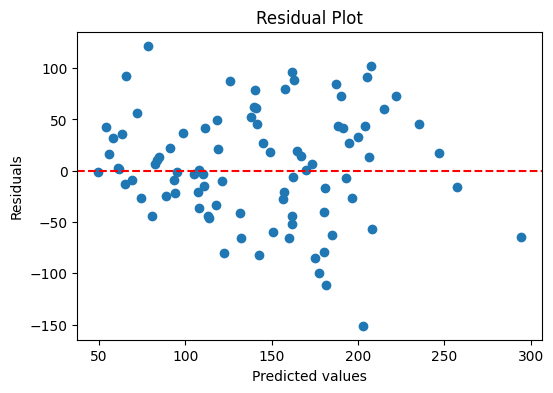

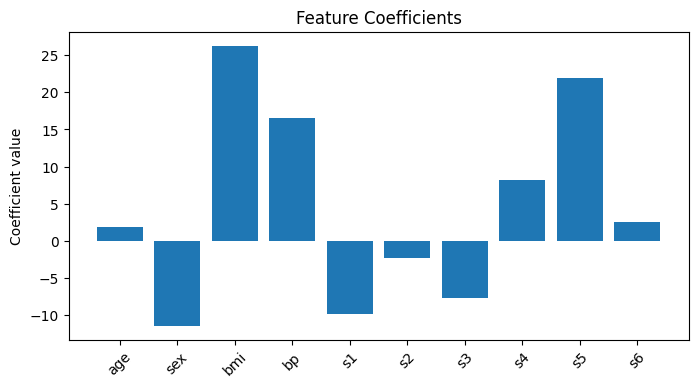

In [6]:
# 5) Predictions
y_pred = model.predict(X_test_scaled)

# Metrics
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
mae = mean_absolute_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print("MSE :", mse)
print("RMSE:", rmse)
print("MAE :", mae)
print("R²  :", r2)

# --- Residual Plot ---
import matplotlib.pyplot as plt

residuals = y_test - y_pred

plt.figure(figsize=(6, 4))
plt.scatter(y_pred, residuals)
plt.axhline(0, color='red', linestyle='--')
plt.xlabel("Predicted values")
plt.ylabel("Residuals")
plt.title("Residual Plot")
plt.show()

# --- Coefficient Bar Chart ---
feature_names = df.drop(columns=["target"]).columns

# If your class stores parameters as theta:
coefficients = model.theta[1:]  # skip intercept

plt.figure(figsize=(8, 4))
plt.bar(feature_names, coefficients)
plt.xticks(rotation=45)
plt.title("Feature Coefficients")
plt.ylabel("Coefficient value")
plt.show()

In [7]:
# TODO: implement here
# Create the required visuals:
# - Correlation heatmap
# - Actual vs predicted plot
# - Residuals vs predicted plot
# - Coefficient bar chart

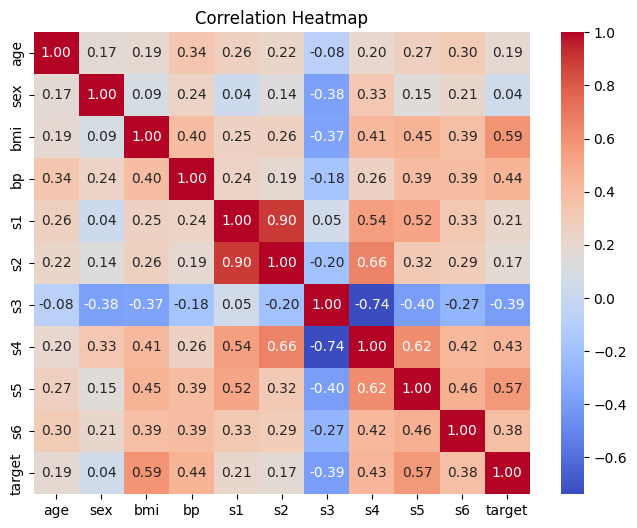

In [8]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# --- 1) Correlation Heatmap ---
plt.figure(figsize=(8, 6))
corr = df.corr()
sns.heatmap(corr, annot=True, cmap="coolwarm", fmt=".2f")
plt.title("Correlation Heatmap")
plt.show()


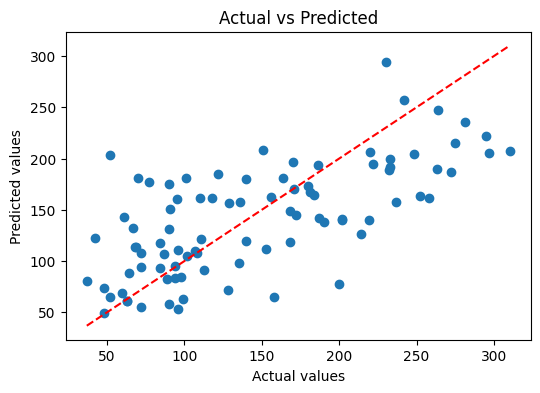

In [9]:
# --- 2) Actual vs Predicted Plot ---
plt.figure(figsize=(6, 4))
plt.scatter(y_test, y_pred)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--')
plt.xlabel("Actual values")
plt.ylabel("Predicted values")
plt.title("Actual vs Predicted")
plt.show()

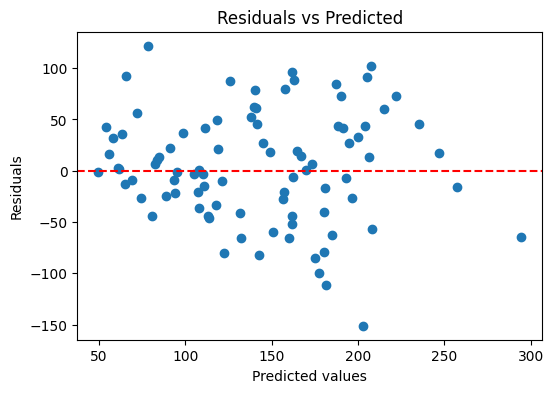

In [10]:
# --- 3) Residuals vs Predicted Plot ---
residuals = y_test - y_pred

plt.figure(figsize=(6, 4))
plt.scatter(y_pred, residuals)
plt.axhline(0, color='red', linestyle='--')
plt.xlabel("Predicted values")
plt.ylabel("Residuals")
plt.title("Residuals vs Predicted")
plt.show()


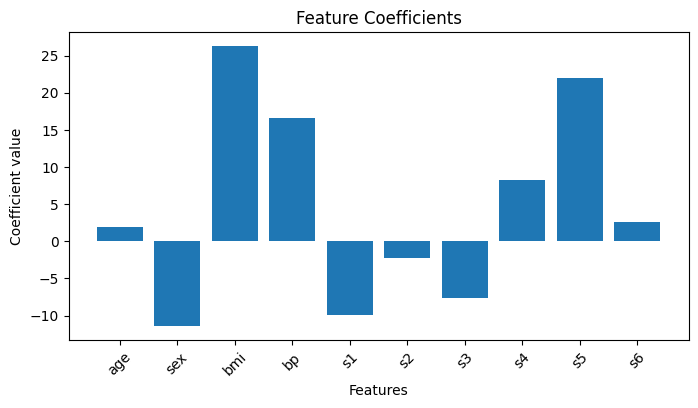

In [11]:
# --- 4) Coefficient Bar Chart ---
feature_names = df.drop(columns=["target"]).columns
coefficients = model.theta[1:]  # skip intercept

plt.figure(figsize=(8, 4))
plt.bar(feature_names, coefficients)
plt.xticks(rotation=45)
plt.xlabel("Features")
plt.ylabel("Coefficient value")
plt.title("Feature Coefficients")
plt.show()

In [ ]:
# TODO: implement here
# Perform regression analysis:
# - Interpret top 3 most influential features
# - Discuss model fit quality
# - Mention obvious issues (e.g., outliers, non-linearity, residual patterns)

## Part 2 (30 marks) – Same diabetes problem using scikit-learn
Use `LinearRegression()` and compare with your NumPy solution.

### Hints — Part 2 (scikit-learn)

- **Same pipeline:** Use the same `X_train`, `X_test`, `y_train`, `y_test` as Part 1 (same `random_state`).
- **Fit:** `LinearRegression().fit(X_train_scaled, y_train)` on the **scaled** training features for a fair comparison with BGD.
- **Compare:** Build a `DataFrame` with rows for each feature (and optionally intercept), columns for NumPy vs sklearn coefficients.
- **Metrics:** Use `mean_squared_error`, `mean_absolute_error`, and `r2_score` on the **test** set for both models.


In [ ]:
# TODO: implement here
# 1) Train LinearRegression() on the same diabetes train/test split
# 2) Compute MSE, RMSE, MAE, R²
# 3) Compare metrics and coefficients with NumPy in a side-by-side DataFrame

In [12]:
import numpy as np
import pandas as pd
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

# 1) Train sklearn model (on SAME scaled data)
lr = LinearRegression()
lr.fit(X_train_scaled, y_train)


LinearRegression()

In [13]:
# 2) Metrics (sklearn)
y_pred_sklearn = lr.predict(X_test_scaled)
mse_sk = mean_squared_error(y_test, y_pred_sklearn)
rmse_sk = np.sqrt(mse_sk)
mae_sk = mean_absolute_error(y_test, y_pred_sklearn)
r2_sk = r2_score(y_test, y_pred_sklearn)

print("=== Sklearn Linear Regression ===")
print("MSE :", mse_sk)
print("RMSE:", rmse_sk)
print("MAE :", mae_sk)
print("R²  :", r2_sk)

=== Sklearn Linear Regression ===
MSE : 2900.1936284934823
RMSE: 53.853445836765935
MAE : 42.79409467959994
R²  : 0.45260276297191926


In [14]:
# Metrics (NumPy / BGD model)
y_pred_bgd = model.predict(X_test_scaled)

mse_bgd = mean_squared_error(y_test, y_pred_bgd)
rmse_bgd = np.sqrt(mse_bgd)
mae_bgd = mean_absolute_error(y_test, y_pred_bgd)
r2_bgd = r2_score(y_test, y_pred_bgd)

print("\n=== NumPy Batch GD ===")
print("MSE :", mse_bgd)
print("RMSE:", rmse_bgd)
print("MAE :", mae_bgd)
print("R²  :", r2_bgd)



=== NumPy Batch GD ===
MSE : 2885.6135403538306
RMSE: 53.71790707346881
MAE : 42.88207217744949
R²  : 0.45535468266612844


In [15]:
# 3) Compare coefficients
feature_names = df.drop(columns=["target"]).columns

# NumPy model coefficients
coef_bgd = model.theta[1:]
intercept_bgd = model.theta[0]

# Sklearn coefficients
coef_sk = lr.coef_
intercept_sk = lr.intercept_

# Create comparison DataFrame
coef_df = pd.DataFrame({
    "Feature": feature_names,
    "BGD_Coefficient": coef_bgd,
    "Sklearn_Coefficient": coef_sk
})

# Add intercept row
intercept_df = pd.DataFrame({
    "Feature": ["Intercept"],
    "BGD_Coefficient": [intercept_bgd],
    "Sklearn_Coefficient": [intercept_sk]
})

coef_df = pd.concat([intercept_df, coef_df], ignore_index=True)

print("\n=== Coefficient Comparison ===")
print(coef_df)


=== Coefficient Comparison ===
      Feature  BGD_Coefficient  Sklearn_Coefficient
0   Intercept       153.736544           153.736544
1         age         1.937195             1.753758
2         sex       -11.432570           -11.511809
3         bmi        26.267164            25.607121
4          bp        16.607099            16.828872
5          s1        -9.879779           -44.448856
6          s2        -2.304101            24.640954
7          s3        -7.683675             7.676978
8          s4         8.201066            13.138784
9          s5        21.950879            35.161195
10         s6         2.602733             2.351364


In [ ]:
# TODO: implement here
# Add a short conclusion on which implementation you prefer and why.

In [ ]:
#I prefer scikit-learn because it is faster, more stable, and requires less manual tuning. The NumPy gradient descent version is mainly useful for learning how linear regression works internally.

## Part 3 (20 marks) – Real-world dataset problem + Regression Analysis
Choose any real-world regression dataset (or reuse California Housing with a feature twist) and apply both NumPy from-scratch and scikit-learn approaches.

### Hints — Part 3 (open-ended)

- **Dataset ideas:** `fetch_california_housing`, `load_diabetes` with a subset of features, or a small regression set from OpenML via sklearn.
- **Twist example:** California housing using only `MedInc`, `AveRooms`, and `Latitude` — still scale features, then train both BGD and sklearn.
- **Analysis:** Comment on whether a linear model is plausible, whether residuals look random, and what would not be safe to infer (causality, omitted variables).
- **Real-world use:** Tie conclusions to decisions (e.g. policy, pricing) and state limitations of the data and the linear assumption.


In [ ]:
# TODO: implement here
# 1) Select a dataset and target
# 2) Preprocess + scale features
# 3) Train NumPy from-scratch model
# 4) Train scikit-learn model
# 5) Compare metrics in a DataFrame

In [16]:
import numpy as np
import pandas as pd

from sklearn.datasets import fetch_california_housing
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

# 1) Load dataset
data = fetch_california_housing(as_frame=True)
df = data.frame

# Select subset of features (twist)
features = ["MedInc", "AveRooms", "Latitude"]
X = df[features].values
y = df["MedHouseVal"].values


In [17]:
# 2) Train-test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [18]:
# 3) Scaling
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)


In [19]:
# 4) NumPy Batch GD model
bgd_model = LinearRegressionBatchGD(learning_rate=0.01, n_iterations=1000)
bgd_model.fit(X_train_scaled, y_train)
y_pred_bgd = bgd_model.predict(X_test_scaled)

In [20]:
# Metrics (BGD)
bgd_metrics = {
    "MSE": mean_squared_error(y_test, y_pred_bgd),
    "RMSE": np.sqrt(mean_squared_error(y_test, y_pred_bgd)),
    "MAE": mean_absolute_error(y_test, y_pred_bgd),
    "R2": r2_score(y_test, y_pred_bgd)
}


In [21]:
# 5) Scikit-learn model
sk_model = LinearRegression()
sk_model.fit(X_train_scaled, y_train)
y_pred_sk = sk_model.predict(X_test_scaled)

# Metrics (Sklearn)
sk_metrics = {
    "MSE": mean_squared_error(y_test, y_pred_sk),
    "RMSE": np.sqrt(mean_squared_error(y_test, y_pred_sk)),
    "MAE": mean_absolute_error(y_test, y_pred_sk),
    "R2": r2_score(y_test, y_pred_sk)
}

In [22]:
# 6) Comparison table
results_df = pd.DataFrame([bgd_metrics, sk_metrics], index=["BatchGD (NumPy)", "Sklearn"])

print(results_df)

                      MSE     RMSE       MAE        R2
BatchGD (NumPy)  0.694188  0.83318  0.621458  0.470251
Sklearn          0.694188  0.83318  0.621458  0.470251


In [23]:
# TODO: implement here
# Create complete regression analysis:
# - Visualizations
# - Coefficient interpretation
# - Short discussion on real-world usefulness for decision making

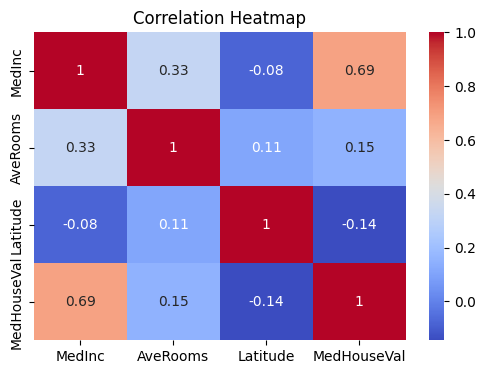

In [24]:

# --- Correlation heatmap ---
plt.figure(figsize=(6,4))
sns.heatmap(df[features + ["MedHouseVal"]].corr(), annot=True, cmap="coolwarm")
plt.title("Correlation Heatmap")
plt.show()

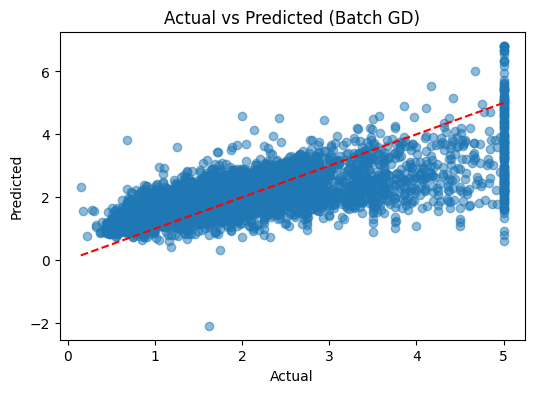

In [25]:
# --- Actual vs Predicted (BGD) ---
plt.figure(figsize=(6,4))
plt.scatter(y_test, y_pred_bgd, alpha=0.5)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--')
plt.xlabel("Actual")
plt.ylabel("Predicted")
plt.title("Actual vs Predicted (Batch GD)")
plt.show()


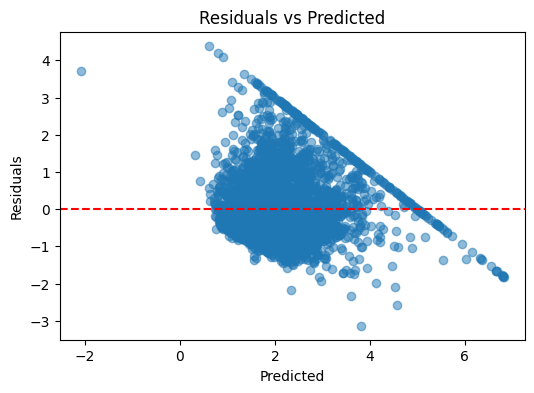

In [26]:
# --- Residuals ---
residuals = y_test - y_pred_bgd

plt.figure(figsize=(6,4))
plt.scatter(y_pred_bgd, residuals, alpha=0.5)
plt.axhline(0, color='red', linestyle='--')
plt.xlabel("Predicted")
plt.ylabel("Residuals")
plt.title("Residuals vs Predicted")
plt.show()

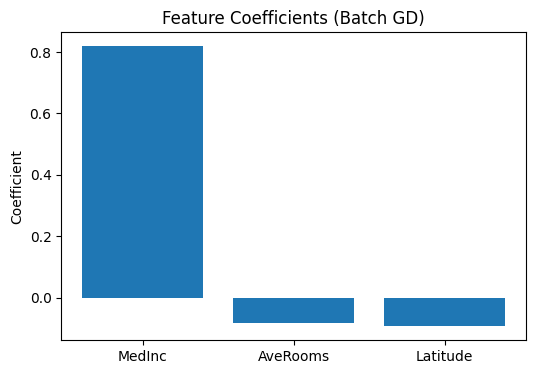

In [27]:
# --- Coefficients ---
plt.figure(figsize=(6,4))
plt.bar(features, bgd_model.theta[1:])
plt.title("Feature Coefficients (Batch GD)")
plt.ylabel("Coefficient")
plt.show()